# UIUC Housing – Property & Pricing EDA
**담당: 세연**  
대상 아파트 12개에 대한 apartments.com / Zillow 데이터 클리닝 및 통합

## 0. Setup

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 30)
pd.set_option('display.max_colwidth', 60)

# ── 대상 12개 아파트 ──────────────────────────────────────
TARGET = {
    'HERE':         '308 E Green',
    'HUB':          '812 S 6th',
    'DEAN':         '708 S 6th',
    'ICON':         '309 E Springfield',
    'Gregory':      '1107 S 4th',
    'Yugo':         '410 N Lincoln',
    'Latitude':     '608 E University',
    'T3':           '302 E John',
    'Seven07':      '707 S 4th',
    'Octave':       '210 S 4th',
    '75 Armory':    '75 E Armory',
    'Illini Manor': '401 E Chalmers',
}

---
## 1. Apartments.com 데이터 클리닝

### 1-1. 원본 로드 & 기본 확인

In [2]:
with open('apartmentscom-raw.json') as f:
    raw_apts = json.load(f)

print(f'총 항목 수: {len(raw_apts)}')
print(f'첫 번째 항목 키 개수: {len(raw_apts[0].keys())}')

# 전체 propertyName + address 목록
for i, item in enumerate(raw_apts):
    print(f"  [{i:02d}] {item.get('propertyName', '?'):45s} | {item.get('fullAddress', '?')}")

총 항목 수: 57
첫 번째 항목 키 개수: 116
  [00] 1009 S 2nd St                                 | 1009 S 2nd St Champaign IL 61820 US
  [01] The Landing at Legends | Specials Available   | 4503 Legends Dr Champaign IL 61822 US
  [02] Maywood Apartments                            | 51 E John St Champaign IL 61820 US
  [03] 202 E. Green St by Bankier Apartments         | 202 E Green St Champaign IL 61820 US
  [04] Latitude | Student Housing                    | 608 E University Ave Champaign IL 61820 US
  [05] BRAND NEW The Station @ 505 S Fifth           | 505 S 5th St Champaign IL 61820 US
  [06] Pacifica on Green                             | 28 E Green St Champaign IL 61820 US
  [07] Alley Lofts at The Pilot                      | 312 S Prairie St Champaign IL 61820 US
  [08] 611 S State St                                | 611 S State St Champaign IL 61820 US
  [09] Onyx Apartments                               | 1321 N Lincoln Ave Urbana IL 61801 US
  [10] The Whitney Apartments                  

### 1-2. 12개 아파트 필터링

> **현황**: scraper가 Champaign 전체를 긁어서 57개가 있고,  
> 그 중 12개 대상에 해당하는 건 **Latitude(index 4)** 와 **Seven07(index 34)** 두 개만 있어.  
> 나머지 10개는 apartments.com에 리스팅이 없거나 다른 검색어로 scrape 해야 해.

**TODO**: 빠진 10개는 직접 URL로 scrape 하거나, 수동으로 채워야 할 수 있어.

In [3]:
def normalize_addr(s):
    """주소 비교용 정규화 – 숫자/알파벳만 소문자로"""
    return ''.join(c.lower() for c in s if c.isalnum())

matched = {}
for name, addr in TARGET.items():
    addr_norm = normalize_addr(addr)
    for item in raw_apts:
        full = item.get('fullAddress', '') + ' ' + item.get('streetAddress', '')
        if addr_norm in normalize_addr(full):
            matched[name] = item
            break

print(f'매칭된 아파트: {list(matched.keys())}')
print(f'매칭 안 된 아파트: {[k for k in TARGET if k not in matched]}')

매칭된 아파트: ['Latitude', 'Seven07']
매칭 안 된 아파트: ['HERE', 'HUB', 'DEAN', 'ICON', 'Gregory', 'Yugo', 'T3', 'Octave', '75 Armory', 'Illini Manor']


### 1-3. 매칭된 항목에서 유닛별 가격 파싱 (rentals)

apartments.com의 `rentals` 필드에 실제 unit-level 가격 정보가 있어.

In [4]:
def parse_rentals(name, item):
    rows = []
    rentals = item.get('rentals') or []
    for r in rentals:
        # RentalType 1 = model-level (대표), 2 = unit-level (개별)
        if r.get('RentalType') != 1:   # model-level만 쓰면 중복 방지
            continue
        rows.append({
            'apt_name':        name,
            'address':         item.get('fullAddress'),
            'unit_name':       r.get('Name'),
            'beds':            r.get('Beds'),
            'baths':           r.get('Baths'),
            'sqft':            r.get('SquareFeet'),
            'sqft_max':        r.get('MaxSquareFeet'),
            'rent_min':        r.get('Rent'),
            'rent_max':        r.get('MaxRent'),
            'total_min':       r.get('MinTotalMonthlyPrice'),  # fees 포함
            'total_max':       r.get('MaxTotalMonthlyPrice'),
            'available':       r.get('AvailableDateText'),
            'lease_min_mo':    r.get('MinLeaseTerm'),
            'lease_max_mo':    r.get('MaxLeaseTerm'),
            'unit_count':      r.get('UnitCount'),
        })
    return rows

all_rows = []
for name, item in matched.items():
    all_rows.extend(parse_rentals(name, item))

df_apts = pd.DataFrame(all_rows)
print(f'shape: {df_apts.shape}')
df_apts

shape: (17, 15)


,apt_name,address,unit_name,beds,baths,sqft,sqft_max,rent_min,rent_max,total_min,total_max,available,lease_min_mo,lease_max_mo,unit_count
0,Latitude,608 E University Ave Champaign IL 61820 US,1BR,1,1,507,507,1539,1579,1685,1725,Available Now,11,18,141
1,Latitude,608 E University Ave Champaign IL 61820 US,1BR - Master,1,1,625,625,1569,1719,1715,1865,Available Now,11,18,76
2,Latitude,608 E University Ave Champaign IL 61820 US,Signature Series - 1 Bedroom w/ Patio,1,1,650,650,1929,1999,2075,2145,Available Now,11,18,1
3,Latitude,608 E University Ave Champaign IL 61820 US,2 Bedroom,2,2,898,898,1049,1069,1195,1215,Available Now,11,18,63
4,Latitude,608 E University Ave Champaign IL 61820 US,4 Bedroom,4,4,1604,1604,929,989,1075,1135,Available Now,11,18,44
5,Seven07,707 S 4th St Champaign IL 61820 US,Studio - Type 2,0,1,422,422,1749,1749,1749,1749,Available Now,6,11,22
6,Seven07,707 S 4th St Champaign IL 61820 US,Studio - Type 1,0,1,539,539,1939,1939,1939,1939,Available Now,6,11,11
7,Seven07,707 S 4th St Champaign IL 61820 US,1BR/1BA,1,1,492,492,2049,2049,2049,2049,Aug 16,11,11,32
8,Seven07,707 S 4th St Champaign IL 61820 US,2BR/2BA - Type 1,2,2,696,696,1349,1349,1349,1349,Available Now,6,11,11
9,Seven07,707 S 4th St Champaign IL 61820 US,2BR/2BA - Type 2,2,2,788,788,1349,1349,1349,1349,Available Now,6,11,21


### 1-4. Utilities / Fees 파싱

In [5]:
def parse_fees(item):
    tf = item.get('transparentFee') or {}
    result = {}

    # UtilitiesAndEssentials
    utils = tf.get('UtilitiesAndEssentials') or []
    result['utilities_included'] = [u.get('FeeDisplayName') for u in utils]

    # Parking
    parking = tf.get('Parking') or []
    result['parking_options'] = [p.get('FeeDisplayName') for p in parking]

    # Pets
    pets = tf.get('Pets') or []
    result['pet_policy'] = [p.get('FeeDisplayName') for p in pets]

    # OneTimeBasics (application/admin fee)
    one_time = tf.get('OneTimeBasics') or []
    result['one_time_fees'] = [
        f"{o.get('FeeDisplayName')}: {o.get('FeeAmount', '?')}"
        for o in one_time
    ]

    return result

fee_rows = []
for name, item in matched.items():
    row = {'apt_name': name}
    row.update(parse_fees(item))
    fee_rows.append(row)

df_fees = pd.DataFrame(fee_rows)
df_fees

,apt_name,utilities_included,parking_options,pet_policy,one_time_fees
0,Latitude,"[Short Term Fee, Building Protection Fee, Utility Fee]",[Parking Fee],"[One-Time Pet Fee, One-Time Pet Fee, Monthly Pet Fee, Mo...","[Administrative Fee: 125, Application Fee Per Applicant:..."
1,Seven07,"[Utility - Water/Sewer, Utility - Electric]",[Parking Fee],"[Pet Deposit, Pet Deposit, One-Time Pet Fee, One-Time Pe...","[Administrative Fee: 150, Application Fee: 50, Utility -..."


### 1-5. Amenities 파싱

In [6]:
def parse_amenities(item):
    """property-level amenities 리스트로"""
    result = []
    for group in (item.get('amenities') or []):
        if not group:
            continue
        for val in (group.get('value') or []):
            result.append(val)
    return result

def parse_unit_amenities(item):
    """unit-level amenities – rentals[0] (RentalType==1)의 InteriorAmenities에서"""
    result = []
    for r in (item.get('rentals') or []):
        if r.get('RentalType') != 1:
            continue
        ia = r.get('InteriorAmenities') or {}
        for sub in (ia.get('SubCategories') or []):
            for amenity in (sub.get('Amenities') or []):
                result.append(amenity.get('Name'))
        break  # 첫 번째 model만
    return list(set(result))

amenity_rows = []
for name, item in matched.items():
    amenity_rows.append({
        'apt_name':        name,
        'property_amenities': parse_amenities(item),
        'unit_amenities':     parse_unit_amenities(item),
    })

df_amenities = pd.DataFrame(amenity_rows)
df_amenities

,apt_name,property_amenities,unit_amenities
0,Latitude,"[Pool, Fitness Center, Furnished Units Available, Elevat...","[Sprinkler System, Large Bedrooms, Air Conditioning, Gra..."
1,Seven07,"[Pool, Fitness Center, Furnished Units Available, Elevat...","[Views, Air Conditioning, Cable Ready, Granite Counterto..."


### 1-6. 전체 apartments.com cleaned DataFrame 합치기

In [7]:
# property-level 요약 (rent range, address, lat/lng)
prop_rows = []
for name, item in matched.items():
    loc = item.get('location') or {}
    prop_rows.append({
        'apt_name':        name,
        'property_name':   item.get('propertyName'),
        'address':         item.get('fullAddress'),
        'lat':             loc.get('latitude'),
        'lng':             loc.get('longitude'),
        'rent_min':        item.get('listingMinRent'),
        'rent_max':        item.get('listingMaxRent'),
        'beds_range':      item.get('beds'),
        'bath_min':        (item.get('bathrooms') or {}).get('min'),
        'bath_max':        (item.get('bathrooms') or {}).get('max'),
        'source':          'apartments.com',
    })

df_apts_summary = pd.DataFrame(prop_rows)
df_apts_summary

,apt_name,property_name,address,lat,lng,rent_min,rent_max,beds_range,bath_min,bath_max,source
0,Latitude,Latitude | Student Housing,608 E University Ave Champaign IL 61820 US,40.11666,-88.22965,929,1999,4,1,4,apartments.com
1,Seven07,Seven07,707 S 4th St Champaign IL 61820 US,40.10974,-88.23409,1089,2049,2,1,4,apartments.com


---
## 2. Zillow 데이터 클리닝

### 2-1. 원본 로드 & 기본 확인

In [8]:
df_z_raw = pd.read_csv('zillow-raw.csv')
print(f'shape: {df_z_raw.shape}')
print(f'컬럼 수: {len(df_z_raw.columns)}')
df_z_raw[['address', 'buildingName', 'unformattedPrice',
          'beds', 'baths', 'area',
          'hdpData/homeInfo/homeType',
          'hdpData/homeInfo/homeStatus']].head(10)

shape: (80, 181)
컬럼 수: 181


,address,buildingName,unformattedPrice,beds,baths,area,hdpData/homeInfo/homeType,hdpData/homeInfo/homeStatus
0,"402 S Busey Ave, Urbana, IL 61801",NaN,3300.0,6.0,3.0,2900.0,SINGLE_FAMILY,FOR_RENT
1,"1008 S Busey Ave APT 5, Urbana, IL 61801",NaN,1075.0,2.0,1.0,900.0,APARTMENT,FOR_RENT
2,"808 Springfield Ave #2, Urbana, IL 61801",NaN,1000.0,2.0,1.0,NaN,APARTMENT,FOR_RENT
3,"707 W Elm St #4, Urbana, IL 61801",NaN,970.0,2.0,1.0,850.0,APARTMENT,FOR_RENT
4,"1010 Springfield Ave #304, Urbana, IL 61801",NaN,725.0,0.0,1.0,NaN,APARTMENT,FOR_RENT
5,"1002 W Hill St #A, Urbana, IL 61801",NaN,1600.0,4.0,2.0,NaN,APARTMENT,FOR_RENT
6,"506 E Stoughton St, Champaign, IL",NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,"2 bed, 1.0 bath, 700 sqft, $990, (undisclosed Address), ...",NaN,990.0,2.0,1.0,700.0,APARTMENT,FOR_RENT
8,"2 bed, 1.0 bath, 700 sqft, $990, (undisclosed Address), ...",NaN,750.0,1.0,1.0,300.0,APARTMENT,FOR_RENT
9,"2 bed, 1.0 bath, 700 sqft, $990, (undisclosed Address), ...",NaN,750.0,1.0,1.0,300.0,APARTMENT,FOR_RENT


### 2-2. 필요한 컬럼만 선택 & 이름 정리

In [9]:
ZILLOW_COL_MAP = {
    'address':                          'address',
    'hdpData/homeInfo/streetAddress':   'street_address',
    'buildingName':                     'building_name',
    'unformattedPrice':                 'price',
    'hdpData/homeInfo/bedrooms':        'beds',
    'hdpData/homeInfo/bathrooms':       'baths',
    'hdpData/homeInfo/livingArea':      'sqft',
    'hdpData/homeInfo/homeType':        'home_type',
    'hdpData/homeInfo/homeStatus':      'status',
    'hdpData/homeInfo/rentZestimate':   'rent_zestimate',
    'hdpData/homeInfo/city':            'city',
    'hdpData/homeInfo/state':           'state',
    'hdpData/homeInfo/zipcode':         'zipcode',
    'hdpData/homeInfo/latitude':        'lat',
    'hdpData/homeInfo/longitude':       'lng',
    'hdpData/homeInfo/daysOnZillow':    'days_on_zillow',
    'detailUrl':                        'detail_url',
}

existing = {k: v for k, v in ZILLOW_COL_MAP.items() if k in df_z_raw.columns}
df_z = df_z_raw[list(existing.keys())].rename(columns=existing).copy()
print(f'선택된 컬럼: {list(df_z.columns)}')
print(f'shape: {df_z.shape}')
df_z.head(5)

선택된 컬럼: ['address', 'street_address', 'building_name', 'price', 'beds', 'baths', 'sqft', 'home_type', 'status', 'rent_zestimate', 'city', 'state', 'zipcode', 'lat', 'lng', 'days_on_zillow', 'detail_url']
shape: (80, 17)


,address,street_address,building_name,price,beds,baths,sqft,home_type,status,rent_zestimate,city,state,zipcode,lat,lng,days_on_zillow,detail_url
0,"402 S Busey Ave, Urbana, IL 61801",402 S Busey Ave,NaN,3300.0,6.0,3.0,2900.0,SINGLE_FAMILY,FOR_RENT,3204.0,Urbana,IL,61801.0,40.109623,-88.21739,64.0,https://www.zillow.com/homedetails/402-S-Busey-Ave-Urban...
1,"1008 S Busey Ave APT 5, Urbana, IL 61801",1008 S Busey Ave APT 5,NaN,1075.0,2.0,1.0,900.0,APARTMENT,FOR_RENT,1192.0,Urbana,IL,61801.0,40.104015,-88.21734,48.0,https://www.zillow.com/homedetails/1008-S-Busey-Ave-APT-...
2,"808 Springfield Ave #2, Urbana, IL 61801",808 Springfield Ave #2,NaN,1000.0,2.0,1.0,NaN,APARTMENT,FOR_RENT,1023.0,Urbana,IL,61801.0,40.112850,-88.21875,24.0,https://www.zillow.com/homedetails/808-Springfield-Ave-2...
3,"707 W Elm St #4, Urbana, IL 61801",707 W Elm St #4,NaN,970.0,2.0,1.0,850.0,APARTMENT,FOR_RENT,1656.0,Urbana,IL,61801.0,40.111206,-88.21690,17.0,https://www.zillow.com/homedetails/707-W-Elm-St-4-Urbana...
4,"1010 Springfield Ave #304, Urbana, IL 61801",1010 Springfield Ave #304,NaN,725.0,0.0,1.0,NaN,APARTMENT,FOR_RENT,803.0,Urbana,IL,61801.0,40.113007,-88.22184,166.0,https://www.zillow.com/homedetails/1010-Springfield-Ave-...


### 2-3. 기본 클리닝

In [10]:
# 1) price 없는 행 제거 (주소만 있고 실제 데이터 없는 행)
before = len(df_z)
df_z = df_z.dropna(subset=['price'])
print(f'price NaN 제거: {before} → {len(df_z)} 행')

# 2) undisclosed address 제거
before = len(df_z)
df_z = df_z[~df_z['street_address'].str.contains('undisclosed', case=False, na=False)]
print(f'undisclosed address 제거: {before} → {len(df_z)} 행')

# 3) status가 FOR_RENT인 것만 (혹시 매매 섞인 경우)
if 'status' in df_z.columns:
    before = len(df_z)
    df_z = df_z[df_z['status'].isin(['FOR_RENT', None]) | df_z['status'].isna()]
    print(f'FOR_RENT 필터: {before} → {len(df_z)} 행')

# 4) 중복 제거 (같은 street_address + price)
before = len(df_z)
df_z = df_z.drop_duplicates(subset=['street_address', 'price'])
print(f'중복 제거: {before} → {len(df_z)} 행')

# 5) price를 int로
df_z['price'] = df_z['price'].astype(int)

# 6) beds / baths 정수 변환
df_z['beds'] = df_z['beds'].fillna(0).astype(int)
df_z['baths'] = df_z['baths'].fillna(0).astype(float)

# 7) 인덱스 리셋
df_z = df_z.reset_index(drop=True)

print(f'\n최종 shape: {df_z.shape}')
df_z.head(10)

price NaN 제거: 80 → 48 행
undisclosed address 제거: 48 → 45 행
FOR_RENT 필터: 45 → 45 행
중복 제거: 45 → 45 행

최종 shape: (45, 17)


,address,street_address,building_name,price,beds,baths,sqft,home_type,status,rent_zestimate,city,state,zipcode,lat,lng,days_on_zillow,detail_url
0,"402 S Busey Ave, Urbana, IL 61801",402 S Busey Ave,NaN,3300,6,3.0,2900.0,SINGLE_FAMILY,FOR_RENT,3204.0,Urbana,IL,61801.0,40.109623,-88.217390,64.0,https://www.zillow.com/homedetails/402-S-Busey-Ave-Urban...
1,"1008 S Busey Ave APT 5, Urbana, IL 61801",1008 S Busey Ave APT 5,NaN,1075,2,1.0,900.0,APARTMENT,FOR_RENT,1192.0,Urbana,IL,61801.0,40.104015,-88.217340,48.0,https://www.zillow.com/homedetails/1008-S-Busey-Ave-APT-...
2,"808 Springfield Ave #2, Urbana, IL 61801",808 Springfield Ave #2,NaN,1000,2,1.0,NaN,APARTMENT,FOR_RENT,1023.0,Urbana,IL,61801.0,40.112850,-88.218750,24.0,https://www.zillow.com/homedetails/808-Springfield-Ave-2...
3,"707 W Elm St #4, Urbana, IL 61801",707 W Elm St #4,NaN,970,2,1.0,850.0,APARTMENT,FOR_RENT,1656.0,Urbana,IL,61801.0,40.111206,-88.216900,17.0,https://www.zillow.com/homedetails/707-W-Elm-St-4-Urbana...
4,"1010 Springfield Ave #304, Urbana, IL 61801",1010 Springfield Ave #304,NaN,725,0,1.0,NaN,APARTMENT,FOR_RENT,803.0,Urbana,IL,61801.0,40.113007,-88.221840,166.0,https://www.zillow.com/homedetails/1010-Springfield-Ave-...
5,"1002 W Hill St #A, Urbana, IL 61801",1002 W Hill St #A,NaN,1600,4,2.0,NaN,APARTMENT,FOR_RENT,1591.0,Urbana,IL,61801.0,40.119434,-88.220894,13.0,https://www.zillow.com/homedetails/1002-W-Hill-St-A-Urba...
6,"602 E Stoughton St #16, Champaign, IL 61820",602 E Stoughton St #16,NaN,1640,1,1.0,615.0,APARTMENT,FOR_RENT,1410.0,Champaign,IL,61820.0,40.113760,-88.230125,158.0,https://www.zillow.com/homedetails/602-E-Stoughton-St-16...
7,"908 Stoughton St #7, Urbana, IL 61801",908 Stoughton St #7,NaN,1640,2,1.0,678.0,APARTMENT,FOR_RENT,NaN,Urbana,IL,61801.0,40.113830,-88.220190,49.0,https://www.zillow.com/homedetails/908-Stoughton-St-7-Ur...
8,"807 W Illinois St APT 6, Urbana, IL 61801",807 W Illinois St APT 6,NaN,800,1,1.0,550.0,APARTMENT,FOR_RENT,991.0,Urbana,IL,61801.0,40.108784,-88.218860,4.0,https://www.zillow.com/homedetails/807-W-Illinois-St-APT...
9,"307 E White St, Champaign, IL 61820",307 E White St,NaN,1250,0,1.0,342.0,APARTMENT,FOR_RENT,1051.0,Champaign,IL,61820.0,40.114143,-88.234460,49.0,https://www.zillow.com/homedetails/307-E-White-St-Champa...


### 2-4. Zillow에서 12개 아파트 매칭 시도

In [11]:
print('=== Zillow에서 12개 아파트 매칭 결과 ===\n')
for name, addr in TARGET.items():
    # 번지수 + 마지막 단어 (street 이름)로 검색
    parts = addr.lower().split()
    num, street = parts[0], parts[-1]
    mask = (
        df_z['address'].str.lower().str.contains(num, na=False) &
        df_z['address'].str.lower().str.contains(street, na=False)
    )
    hits = df_z[mask]
    if len(hits):
        print(f'✓ {name} ({addr}): {len(hits)}개 유닛')
        print(hits[['address','price','beds','baths','sqft']].to_string(index=False))
    else:
        print(f'✗ {name} ({addr}): NOT FOUND')
    print()

=== Zillow에서 12개 아파트 매칭 결과 ===

✗ HERE (308 E Green): NOT FOUND

✗ HUB (812 S 6th): NOT FOUND

✗ DEAN (708 S 6th): NOT FOUND

✗ ICON (309 E Springfield): NOT FOUND

✗ Gregory (1107 S 4th): NOT FOUND

✗ Yugo (410 N Lincoln): NOT FOUND

✗ Latitude (608 E University): NOT FOUND

✗ T3 (302 E John): NOT FOUND

✗ Seven07 (707 S 4th): NOT FOUND

✗ Octave (210 S 4th): NOT FOUND

✗ 75 Armory (75 E Armory): NOT FOUND

✗ Illini Manor (401 E Chalmers): NOT FOUND



> **결과 해석**: Zillow도 12개 대상 아파트가 거의 없어.  
> 이유는 Zillow가 대형 student housing 건물 전체를 하나의 listing으로 올리지 않고, 개별 unit이나 개인 매물 위주이기 때문이야.  
> → Zillow 데이터는 **Champaign 전체 렌트 시장 benchmark** (평균 가격대, bed/sqft ratio 등)로 활용하는 방향이 더 적합해.

---
## 3. 두 데이터 통합 & EDA

### 3-1. Zillow – Champaign 렌트 시장 baseline

In [12]:
# 이상값 제거: 월세 $300 이하 or $5000 이상은 노이즈
df_z_apt = df_z[(df_z['price'] >= 300) & (df_z['price'] <= 5000)].copy()

print('=== Zillow – Champaign 렌트 전체 통계 ===')
print(df_z_apt['price'].describe().round(0))

print('\n=== beds별 가격 중앙값 ===')
print(df_z_apt.groupby('beds')['price'].agg(['median','mean','count']).round(0))

=== Zillow – Champaign 렌트 전체 통계 ===
count      45.0
mean     1405.0
std       502.0
min       450.0
25%      1190.0
50%      1390.0
75%      1600.0
max      3300.0
Name: price, dtype: float64

=== beds별 가격 중앙값 ===
      median    mean  count
beds                       
0     1190.0  1036.0      7
1     1270.0  1241.0     10
2     1395.0  1371.0     19
3     1868.0  1748.0      4
4     1788.0  1805.0      4
6     3300.0  3300.0      1


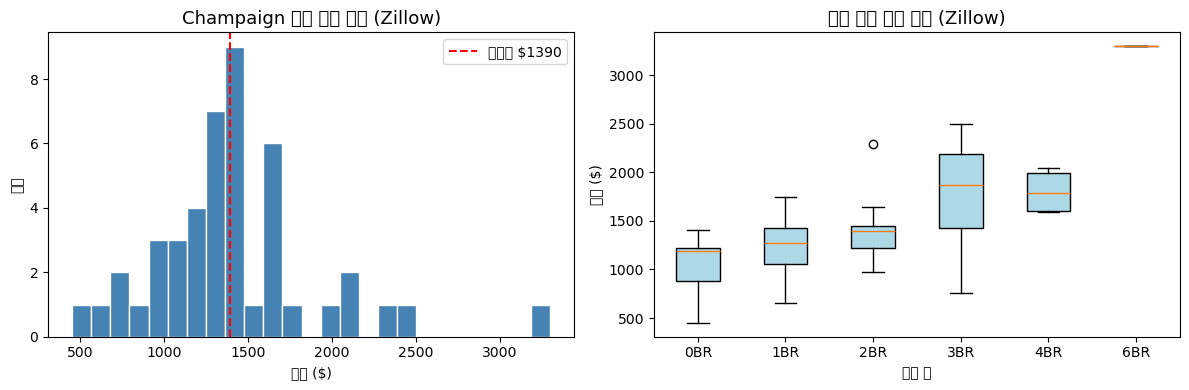

저장: zillow_price_dist.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 가격 분포
axes[0].hist(df_z_apt['price'], bins=25, color='steelblue', edgecolor='white')
axes[0].set_title('Champaign 렌트 가격 분포 (Zillow)', fontsize=13)
axes[0].set_xlabel('월세 ($)')
axes[0].set_ylabel('건수')
axes[0].axvline(df_z_apt['price'].median(), color='red', linestyle='--', label=f'중앙값 ${df_z_apt["price"].median():.0f}')
axes[0].legend()

# beds별 박스플롯
bed_groups = [df_z_apt[df_z_apt['beds'] == b]['price'].dropna() for b in sorted(df_z_apt['beds'].unique())]
axes[1].boxplot(bed_groups, labels=[f'{b}BR' for b in sorted(df_z_apt['beds'].unique())],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title('침실 수별 가격 분포 (Zillow)', fontsize=13)
axes[1].set_xlabel('침실 수')
axes[1].set_ylabel('월세 ($)')

plt.tight_layout()
plt.savefig('zillow_price_dist.png', dpi=120, bbox_inches='tight')
plt.show()
print('저장: zillow_price_dist.png')

### 3-2. apartments.com – 12개 아파트 유닛 가격 비교

=== apartments.com 유닛 가격 요약 ===
                    rent_min  rent_max  total_min  total_max
apt_name bed_label                                          
Latitude 1BR          1679.0    1766.0     1825.0     1912.0
         2BR          1049.0    1069.0     1195.0     1215.0
         4BR           929.0     989.0     1075.0     1135.0
Seven07  1BR          2049.0    2049.0     2049.0     2049.0
         2BR          1374.0    1374.0     1374.0     1374.0
         3BR          1339.0    1339.0     1339.0     1339.0
         4BR          1136.0    1136.0     1136.0     1136.0
         Studio       1844.0    1844.0     1844.0     1844.0


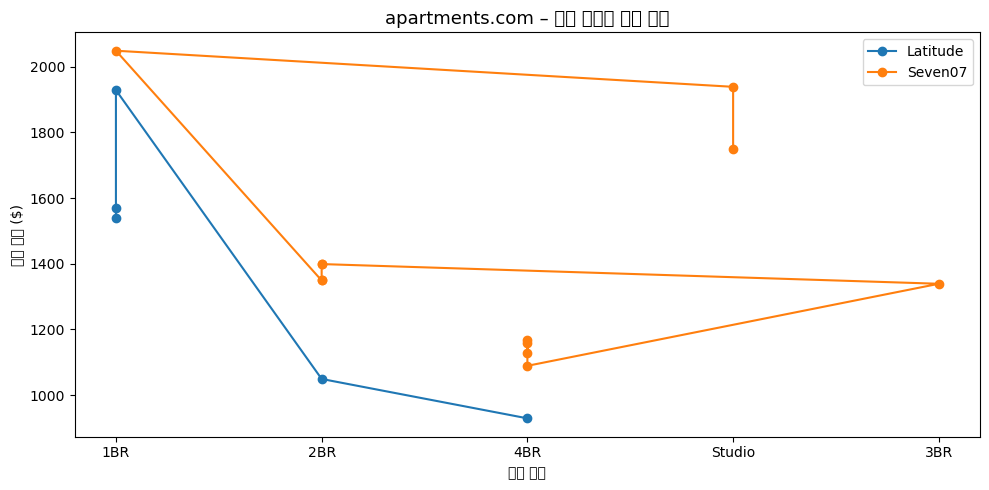

In [14]:
if df_apts.empty:
    print('apartments.com에서 매칭된 아파트가 없어서 이 섹션은 건너뜀')
else:
    # bed_label 추가
    df_apts['bed_label'] = df_apts['beds'].apply(
        lambda b: 'Studio' if b == 0 else f'{int(b)}BR'
    )

    print('=== apartments.com 유닛 가격 요약 ===')
    print(df_apts.groupby(['apt_name', 'bed_label'])[['rent_min','rent_max','total_min','total_max']].mean().round(0))

    fig, ax = plt.subplots(figsize=(10, 5))
    for apt_name in df_apts['apt_name'].unique():
        sub = df_apts[df_apts['apt_name'] == apt_name].sort_values('beds')
        ax.plot(sub['bed_label'], sub['rent_min'], marker='o', label=apt_name)
    ax.set_title('apartments.com – 유닛 타입별 최저 월세', fontsize=13)
    ax.set_xlabel('유닛 타입')
    ax.set_ylabel('최저 월세 ($)')
    ax.legend()
    plt.tight_layout()
    plt.savefig('apts_price_by_unit.png', dpi=120, bbox_inches='tight')
    plt.show()

### 3-3. Utilities 포함 vs 미포함 비교 (apartments.com)

In [15]:
if df_apts.empty:
    print('skip')
else:
    df_cost = df_apts[['apt_name','bed_label','rent_min','total_min']].copy()
    df_cost['fee_gap'] = df_cost['total_min'] - df_cost['rent_min']
    print('=== 공식 월세 vs fees 포함 총액 차이 ===')
    print(df_cost.groupby('apt_name')[['rent_min','total_min','fee_gap']].mean().round(0))

=== 공식 월세 vs fees 포함 총액 차이 ===
          rent_min  total_min  fee_gap
apt_name                              
Latitude    1403.0     1549.0    146.0
Seven07     1426.0     1426.0      0.0


### 3-4. 통합 마스터 테이블 만들기

apartments.com 데이터 + (나중에 추가할) 수동 데이터를 하나로 합쳐서 웹사이트용 데이터셋으로 쓸 거야.

In [16]:
# 현재 apartments.com에서 뽑은 property-level 요약
df_master = df_apts_summary.copy()

# fees 정보 merge
df_master = df_master.merge(
    df_fees[['apt_name','utilities_included','parking_options','one_time_fees']],
    on='apt_name', how='left'
)

# amenities 정보 merge
df_master = df_master.merge(
    df_amenities[['apt_name','unit_amenities']],
    on='apt_name', how='left'
)

# 아직 스크레이프 안 된 아파트는 빈 행으로 추가 (나중에 채우기 위해)
missing_apts = [k for k in TARGET if k not in df_master['apt_name'].values]
missing_rows = pd.DataFrame([{
    'apt_name': name,
    'address': TARGET[name] + ' Champaign IL',
    'source': 'apartments.com',
    'rent_min': None, 'rent_max': None,
} for name in missing_apts])

df_master = pd.concat([df_master, missing_rows], ignore_index=True)
print(f'마스터 테이블 shape: {df_master.shape}')
df_master[['apt_name','address','rent_min','rent_max','utilities_included']]

마스터 테이블 shape: (12, 15)


,apt_name,address,rent_min,rent_max,utilities_included
0,Latitude,608 E University Ave Champaign IL 61820 US,929,1999,"[Short Term Fee, Building Protection Fee, Utility Fee]"
1,Seven07,707 S 4th St Champaign IL 61820 US,1089,2049,"[Utility - Water/Sewer, Utility - Electric]"
2,HERE,308 E Green Champaign IL,None,None,NaN
3,HUB,812 S 6th Champaign IL,None,None,NaN
4,DEAN,708 S 6th Champaign IL,None,None,NaN
5,ICON,309 E Springfield Champaign IL,None,None,NaN
6,Gregory,1107 S 4th Champaign IL,None,None,NaN
7,Yugo,410 N Lincoln Champaign IL,None,None,NaN
8,T3,302 E John Champaign IL,None,None,NaN
9,Octave,210 S 4th Champaign IL,None,None,NaN


### 3-5. Zillow market context – 12개 아파트 가격대 위치 파악

In [17]:
# Zillow 전체 데이터에서 bed별 시장 중앙값
zillow_benchmark = df_z_apt.groupby('beds')['price'].median().reset_index()
zillow_benchmark.columns = ['beds', 'zillow_median_price']
print('Zillow Champaign 렌트 benchmark:')
print(zillow_benchmark)

# apartments.com 유닛과 비교
if not df_apts.empty:
    df_compare = df_apts[['apt_name','beds','rent_min']].merge(
        zillow_benchmark, on='beds', how='left'
    )
    df_compare['vs_market'] = df_compare['rent_min'] - df_compare['zillow_median_price']
    df_compare['vs_market_pct'] = (df_compare['vs_market'] / df_compare['zillow_median_price'] * 100).round(1)
    print('\n시장 대비 가격 비교 (+ = 시장보다 비쌈):')
    print(df_compare[['apt_name','beds','rent_min','zillow_median_price','vs_market_pct']])

Zillow Champaign 렌트 benchmark:
   beds  zillow_median_price
0     0               1190.0
1     1               1270.0
2     2               1395.0
3     3               1867.5
4     4               1787.5
5     6               3300.0

시장 대비 가격 비교 (+ = 시장보다 비쌈):
    apt_name  beds  rent_min  zillow_median_price  vs_market_pct
0   Latitude     1      1539               1270.0           21.2
1   Latitude     1      1569               1270.0           23.5
2   Latitude     1      1929               1270.0           51.9
3   Latitude     2      1049               1395.0          -24.8
4   Latitude     4       929               1787.5          -48.0
5    Seven07     0      1749               1190.0           47.0
6    Seven07     0      1939               1190.0           62.9
7    Seven07     1      2049               1270.0           61.3
8    Seven07     2      1349               1395.0           -3.3
9    Seven07     2      1349               1395.0           -3.3
10   Seven07     2     

---
## 4. 중복 확인

In [18]:
# Zillow 내부 중복 확인
dup_z = df_z_raw.duplicated(subset=['hdpData/homeInfo/streetAddress', 'hdpData/homeInfo/price'], keep=False)
print(f'Zillow 내부 중복 행: {dup_z.sum()}개')
if dup_z.sum() > 0:
    display(df_z_raw[dup_z][['address', 'unformattedPrice']].head(10))

# apartments.com 내부 중복 확인 (listingId 기준)
listing_ids = [item.get('listingId') for item in raw_apts]
dup_count = len(listing_ids) - len(set(listing_ids))
print(f'\napartments.com 내부 중복 listingId: {dup_count}개')

# Cross-source 중복 가능성: 둘 다 주소가 있는 경우 비교
apts_addrs = set(normalize_addr(item.get('fullAddress','')) for item in raw_apts)
zillow_addrs = set(normalize_addr(a) for a in df_z['address'].dropna())
cross_dup = apts_addrs & zillow_addrs
print(f'\n주소 기반 cross-source 중복 가능: {len(cross_dup)}개')

Zillow 내부 중복 행: 34개


,address,unformattedPrice
6,"506 E Stoughton St, Champaign, IL",NaN
8,"2 bed, 1.0 bath, 700 sqft, $990, (undisclosed Address), ...",750.0
9,"2 bed, 1.0 bath, 700 sqft, $990, (undisclosed Address), ...",750.0
10,"605 S 4th St, Champaign, IL",NaN
11,"1004 W Main St, Urbana, IL",NaN
13,"504 E Stoughton St, Champaign, IL",NaN
15,"509 E White St, Champaign, IL",NaN
17,"309 E White St, Champaign, IL",NaN
32,"812 W Main St, Urbana, IL",NaN
35,"709 W Main St, Urbana, IL",NaN



apartments.com 내부 중복 listingId: 0개

주소 기반 cross-source 중복 가능: 0개


---
## 5. CSV 저장 (팀원 공유용)

In [19]:
# Zillow cleaned
df_z.to_csv('zillow-cleaned.csv', index=False)
print('저장: zillow-cleaned.csv')

# apartments.com unit-level
if not df_apts.empty:
    df_apts.to_csv('apts-units-cleaned.csv', index=False)
    print('저장: apts-units-cleaned.csv')

# 마스터 테이블 (웹사이트용 base)
df_master.to_csv('housing-master.csv', index=False)
print('저장: housing-master.csv')

print('\n=== 최종 요약 ===')
print(f'apartments.com: 12개 중 {len(matched)}개 매칭 ({list(matched.keys())})')
print(f'Zillow cleaned: {len(df_z)}행 (Champaign 전체 렌트 시장)')
print(f'마스터 테이블: {len(df_master)}행 (12개 아파트 모두 포함, 미수집분은 빈값)')

저장: zillow-cleaned.csv
저장: apts-units-cleaned.csv
저장: housing-master.csv

=== 최종 요약 ===
apartments.com: 12개 중 2개 매칭 (['Latitude', 'Seven07'])
Zillow cleaned: 45행 (Champaign 전체 렌트 시장)
마스터 테이블: 12행 (12개 아파트 모두 포함, 미수집분은 빈값)


---
## 6. Next Steps

1. **나머지 10개 아파트 scraping**: HERE, HUB, DEAN, ICON, Gregory, Yugo, T3, Octave, 75 Armory, Illini Manor는 아직 데이터 없음.  
   - apartments.com 개별 URL로 직접 scrape하거나 수동 입력 필요.

2. **Utilities 비용 추정**: `estimate_total_cost()` 로직 개선.  
   - 현재는 정액 추가($25/$20 등)인데, 실제 UIUC 평균 유틸리티 비용 기반으로 조정.

3. **팀원 연계**:
   - `housing-master.csv` → 경웅/유진(Reddit), 진우(Google Review), 지현(통학 거리) 팀이 join할 때 `apt_name` 컬럼 기준으로 merge.
   - `zillow-cleaned.csv` → Champaign 전체 시장 context 제공용.